In [1]:
# Imporatando as bibliotecas
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
# Gerando um DataFrame de exemplo com dados randômicos para as colunas "peso (kg)" e "idade (anos)"
# para obter uma amostra de dados não normal
cont, disc = "peso (kg)", "idade (anos)"

mu, sigma = 5, 2 # mean and standard deviation
df = pd.DataFrame({
        cont: np.random.normal(mu, sigma, 1000),
        disc: np.random.normal(mu, sigma, 1000) // 1
    },
).round(2)
df.head()

,peso (kg),idade (anos)
0,6.20,3.0
1,3.53,4.0
2,7.00,1.0
3,4.92,4.0
4,5.19,6.0


In [3]:
# Caracterizando a variável contínua "peso (kg)" em categorias
labels = ['Abaixo', 'Normal', 'Sobrep', 'Obes I', 'Obes II', 'Obes III']
df[cont+" cat"] = pd.cut(df[cont], bins=[-2.0, 0, 2.5, 5, 7.5, 9, 11], labels=labels)
df.head()

,peso (kg),idade (anos),peso (kg) cat
0,6.20,3.0,Obes I
1,3.53,4.0,Sobrep
2,7.00,1.0,Obes I
3,4.92,4.0,Sobrep
4,5.19,6.0,Obes I


In [4]:
# Caracterizando a variável discreta "idade (anos)" em categorias
labels = ['Q1', 'Q2', 'Q3', 'Q4']
df[disc+" cat"] = pd.qcut(df[disc], q=len(labels), labels=labels)
df.head()

,peso (kg),idade (anos),peso (kg) cat,idade (anos) cat
0,6.20,3.0,Obes I,Q1
1,3.53,4.0,Sobrep,Q2
2,7.00,1.0,Obes I,Q1
3,4.92,4.0,Sobrep,Q2
4,5.19,6.0,Obes I,Q3


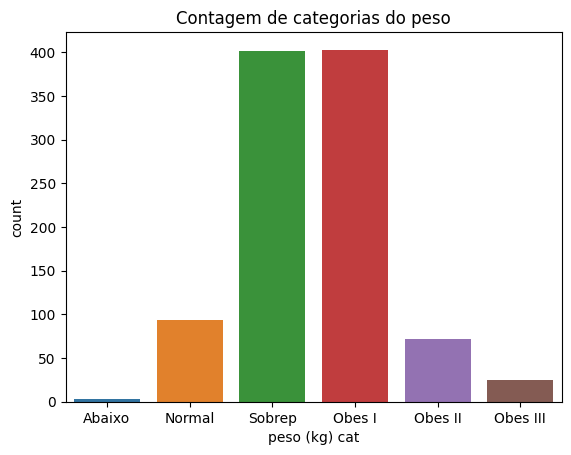

In [5]:
# Plotando a contagem de categorias do peso
sns.countplot(
    x=cont+" cat",
    data=df
)
plt.title("Contagem de categorias do peso")
plt.show()

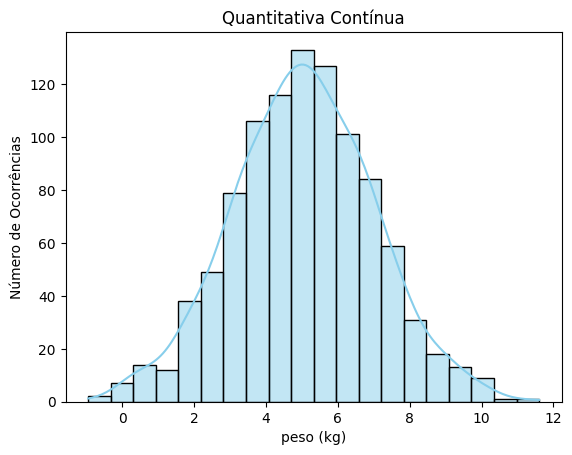

In [6]:
# Plotando a contagem de categorias da idade
sns.histplot(
    x=cont,
    kde=True,
    bins=20,
    color='skyblue',
    data=df,
)
plt.title("Quantitativa Contínua")
plt.xlabel(cont)
plt.ylabel("Número de Ocorrências")
plt.show()

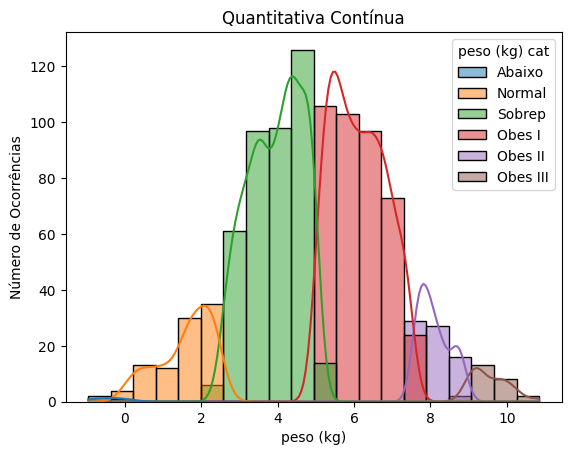

In [7]:
# Plotando histograma do peso categorizado por idade categorizada
sns.histplot(
    x=cont,
    kde=True,
    bins=20,
    color='skyblue',
    hue=cont+" cat",
    data=df,
)
plt.title("Quantitativa Contínua")
plt.xlabel(cont)
plt.ylabel("Número de Ocorrências")
plt.show()

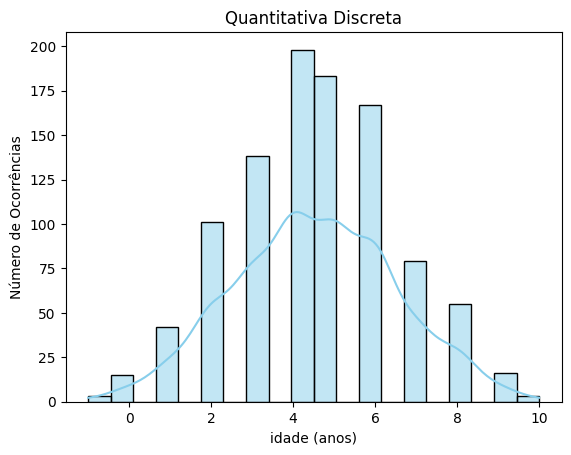

In [8]:
# Plotando histograma da idade categorizada por peso categorizado
sns.histplot(
    x=disc,
    kde=True,
    bins=20,
    color='skyblue',
    data=df,
)
plt.title("Quantitativa Discreta")
plt.xlabel(disc)
plt.ylabel("Número de Ocorrências")
plt.show()

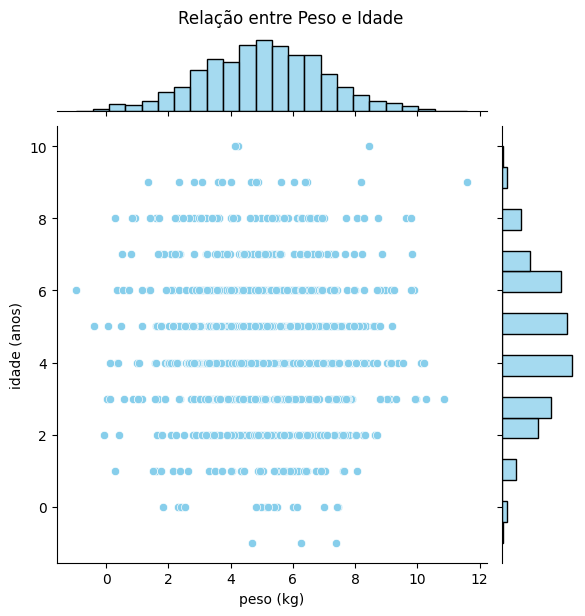

In [9]:
# Plotando histograma da idade categorizada por peso categorizado
sns.jointplot(
    x=cont,
    y=disc,
    data=df,
    kind='scatter',
    color='skyblue',
)
plt.suptitle("Relação entre Peso e Idade", y=1.02)
plt.xlabel(cont)
plt.ylabel(disc)
plt.show()

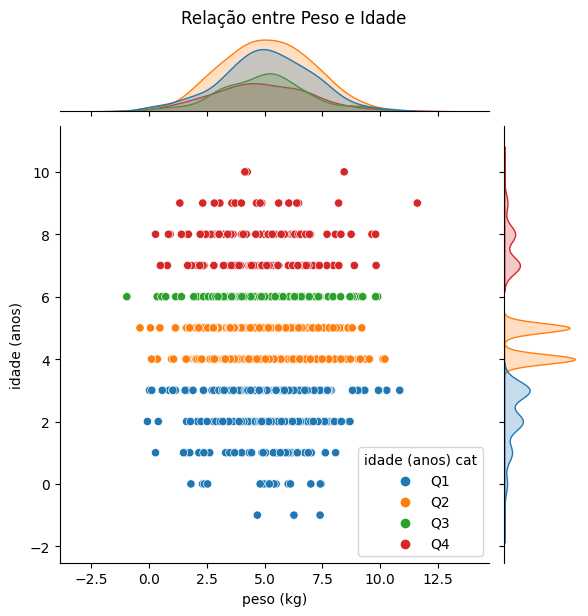

In [10]:
# Plotando histograma da idade categorizada por peso categorizado, com a idade categorizada por quartis
sns.jointplot(
    x=cont,
    y=disc,
    data=df,
    hue=disc+" cat",
    kind='scatter',
    color='skyblue',
)
plt.suptitle("Relação entre Peso e Idade", y=1.02)
plt.xlabel(cont)
plt.ylabel(disc)
plt.show()